# Notebook 03 — Spatio-Temporal Analysis
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D3 (Part 1) — Geographic & Time-Based Complaint Pattern Detection  
**Author:** Ouerghi Chaima

---
## Table of Contents
1. Environment Setup
2. Load Data
3. Geographic Hotspot Analysis
4. Temporal Pattern Analysis
5. Hour × Day-of-Week Heatmap
6. Anomaly Burst Detection
7. Service-Type Segmentation by Region
8. Cell-Level Hotspot Analysis
9. Summary


## 1. Environment Setup

In [1]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS  = sns.color_palette('husl', 10)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)

print('Environment ready ✓')

Environment ready ✓


## 2. Load Data

In [2]:
complaints_clean = pd.read_parquet('data/processed/complaints_clean.parquet')
complaint_agg    = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg          = pd.read_parquet('data/processed/kpi_daily_agg.parquet')

complaints_clean['timestamp'] = pd.to_datetime(complaints_clean['timestamp'])
complaint_agg['date']         = pd.to_datetime(complaint_agg['date'])

print(f'complaints_clean : {complaints_clean.shape}')
print(f'complaint_agg    : {complaint_agg.shape}')
print(f'kpi_agg          : {kpi_agg.shape}')
print('All datasets loaded ✓')

complaints_clean : (50000, 23)
complaint_agg    : (5460, 29)
kpi_agg          : (5460, 108)
All datasets loaded ✓


In [3]:
from src.analysis.spatiotemporal import SpatioTemporalAnalyser

st      = SpatioTemporalAnalyser()
results = st.run(complaints_clean, complaint_agg, kpi_agg)

2026-03-30 06:04:13.267 | INFO     | src.analysis.spatiotemporal:run:103 - ============================================================
2026-03-30 06:04:13.268 | INFO     | src.analysis.spatiotemporal:run:104 - SPATIO-TEMPORAL ANALYSIS
2026-03-30 06:04:13.270 | INFO     | src.analysis.spatiotemporal:run:105 - ============================================================
2026-03-30 06:04:13.288 | INFO     | src.analysis.spatiotemporal:run:113 - 
[1/6] Geographic hotspot mapping ...
2026-03-30 06:04:13.418 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:222 -   Regional hotspot ranking:
2026-03-30 06:04:13.425 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:224 -     #1 Sousse        5,076 complaints  QoE=65.6
2026-03-30 06:04:13.426 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:224 -     #2 Ariana        5,056 complaints  QoE=65.6
2026-03-30 06:04:13.428 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:224 -     #3 Monastir      5,

## 3. Geographic Hotspot Analysis

In [4]:
regional = results['regional_hotspots']
print('=== Regional Hotspot Rankings ===')
display(regional[['hotspot_rank','region','total_complaints',
                   'complaint_rate_per_day','dominant_category',
                   'dominant_service','avg_qoe_score',
                   'high_priority_pct']].to_string(index=False))

=== Regional Hotspot Rankings ===


' hotspot_rank    region  total_complaints  complaint_rate_per_day       dominant_category dominant_service  avg_qoe_score  high_priority_pct\n            1    Sousse              5076                    9.30 Intermittent Connection            Voice          65.62               25.0\n            2    Ariana              5056                    9.26 Intermittent Connection            Voice          65.61               25.6\n            3  Monastir              5050                    9.25 Intermittent Connection            Voice          65.70               25.1\n            4   Bizerte              5014                    9.18 Intermittent Connection            Voice          65.66               24.9\n            5      Sfax              5002                    9.16 Intermittent Connection            Voice          65.66               24.4\n            6  Kairouan              5000                    9.16 Intermittent Connection            Voice          65.66               24.8\n     

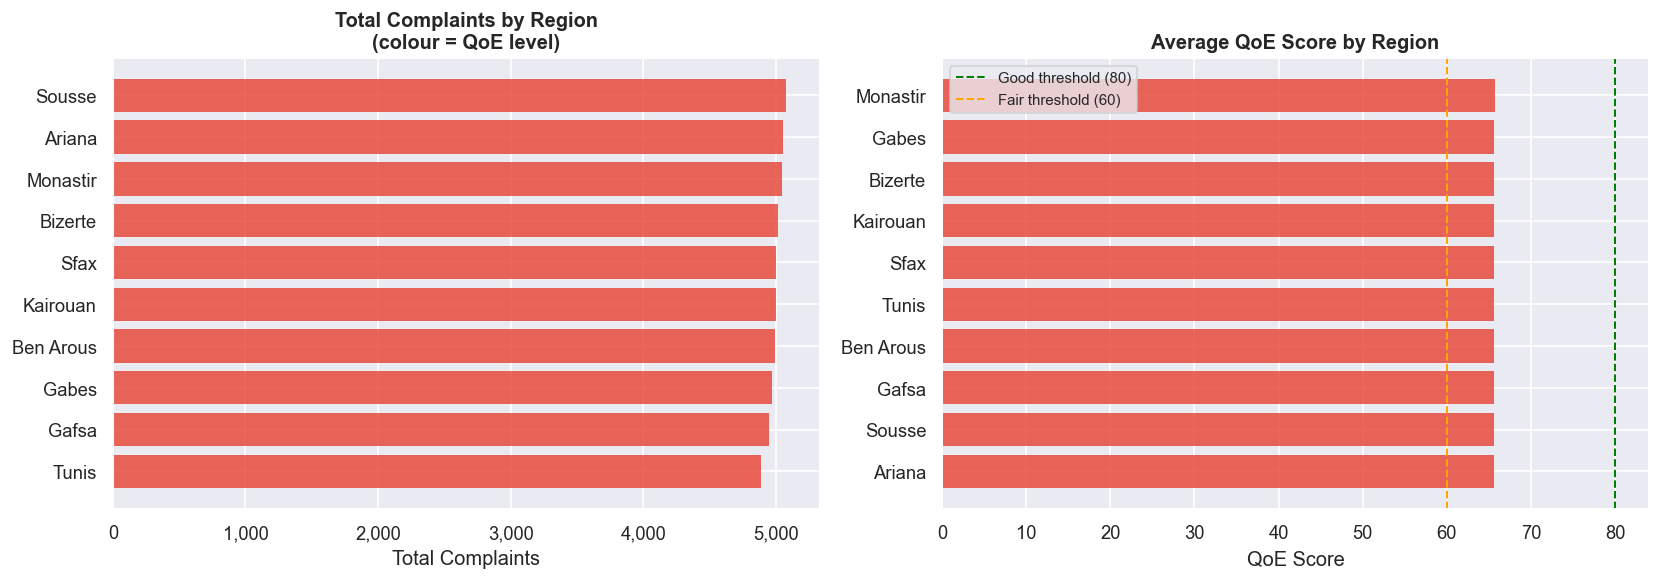

In [5]:
# 3.1 Regional complaint volume + QoE side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_sorted = regional.sort_values('total_complaints')
bar_colors = ['#e74c3c' if qoe < 75 else '#f39c12' if qoe < 82
               else '#2ecc71'
               for qoe in reg_sorted.get('avg_qoe_score', [75]*len(reg_sorted))]

axes[0].barh(reg_sorted['region'], reg_sorted['total_complaints'],
             color=bar_colors, edgecolor='none', alpha=0.85)
axes[0].set_title('Total Complaints by Region\n(colour = QoE level)',
                   fontweight='bold')
axes[0].set_xlabel('Total Complaints')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# QoE score by region
if 'avg_qoe_score' in regional.columns:
    reg_qoe = regional.sort_values('avg_qoe_score')
    qoe_colors = ['#e74c3c' if q < 75 else '#f39c12' if q < 82
                   else '#2ecc71' for q in reg_qoe['avg_qoe_score']]
    axes[1].barh(reg_qoe['region'], reg_qoe['avg_qoe_score'],
                 color=qoe_colors, edgecolor='none', alpha=0.85)
    axes[1].axvline(80, color='green',  linestyle='--', lw=1.2,
                    label='Good threshold (80)')
    axes[1].axvline(60, color='orange', linestyle='--', lw=1.2,
                    label='Fair threshold (60)')
    axes[1].set_title('Average QoE Score by Region', fontweight='bold')
    axes[1].set_xlabel('QoE Score')
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/st_regional_complaints_qoe.png',
            dpi=150, bbox_inches='tight')
plt.show()

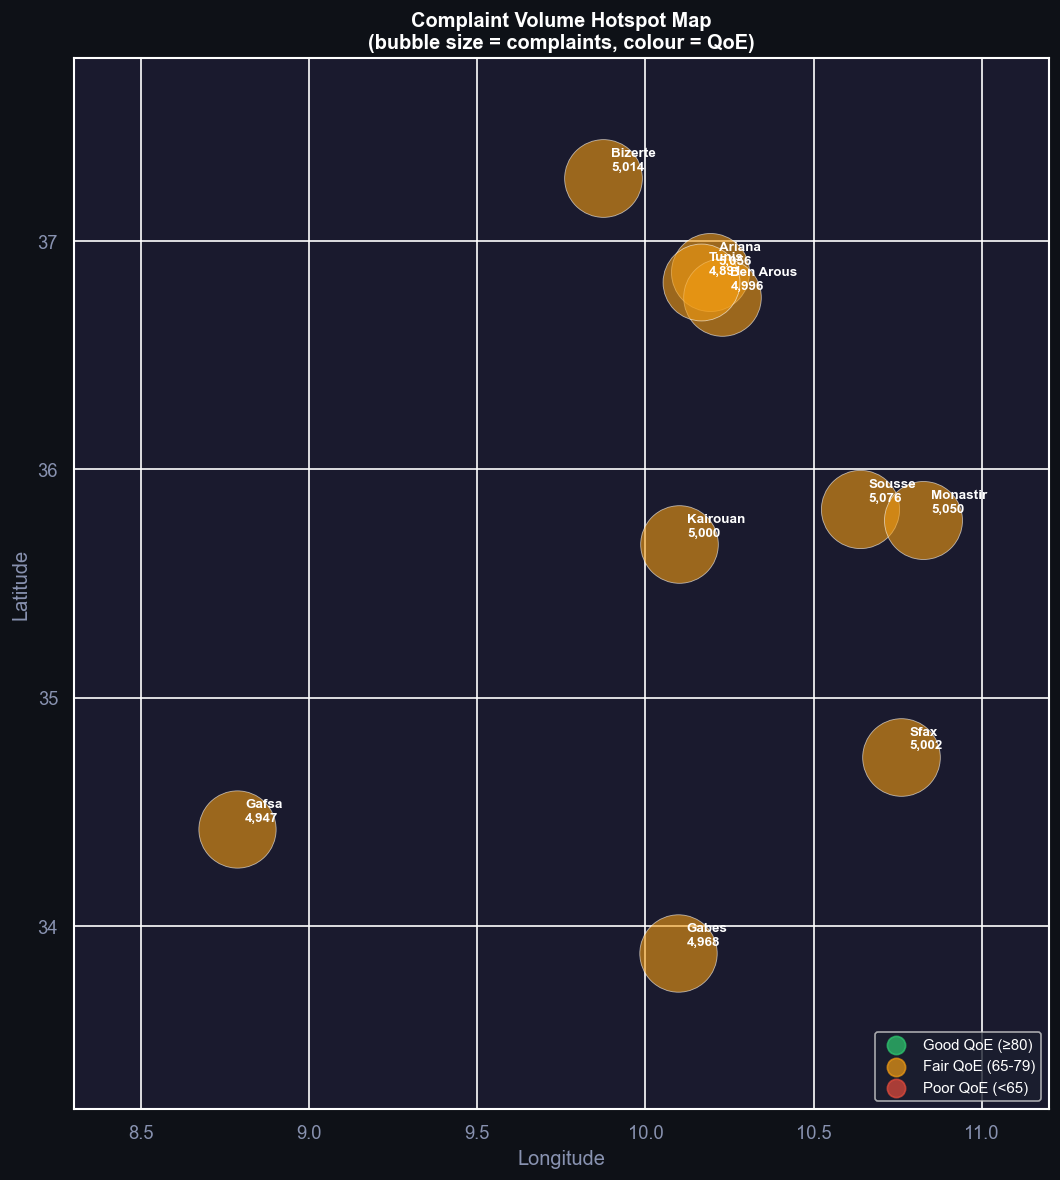

Interactive map saved → reports/exports/st_regional_map.html


In [6]:
# 3.2 Bubble map (matplotlib — no folium needed for thesis figures)
REGION_COORDS = {
    'Tunis':    (36.818, 10.165), 'Sfax':     (34.740, 10.760),
    'Sousse':   (35.825, 10.638), 'Kairouan': (35.671, 10.100),
    'Bizerte':  (37.275,  9.873), 'Gabes':    (33.881, 10.097),
    'Ariana':   (36.862, 10.193), 'Gafsa':    (34.422,  8.784),
    'Monastir': (35.777, 10.826), 'Ben Arous':(36.753, 10.228),
}

fig, ax = plt.subplots(figsize=(9, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0e1117')

max_c = regional['total_complaints'].max()
for _, row in regional.iterrows():
    region = row['region']
    if region not in REGION_COORDS:
        continue
    lat, lon = REGION_COORDS[region]
    count    = row['total_complaints']
    qoe      = row.get('avg_qoe_score', 70)
    size     = 200 + (count / max_c) * 2000
    color    = ('#2ecc71' if qoe >= 80 else
                '#f39c12' if qoe >= 65 else '#e74c3c')

    ax.scatter(lon, lat, s=size, color=color,
               alpha=0.6, edgecolors='white', linewidths=0.5)
    ax.annotate(f'{region}\n{count:,}',
                (lon, lat), textcoords='offset points',
                xytext=(5, 5), color='white', fontsize=8,
                fontweight='bold')

ax.set_xlim(8.3, 11.2)
ax.set_ylim(33.2, 37.8)
ax.set_title('Complaint Volume Hotspot Map\n(bubble size = complaints, colour = QoE)',
             color='white', fontweight='bold', fontsize=12)
ax.set_xlabel('Longitude', color='#8892b0')
ax.set_ylabel('Latitude',  color='#8892b0')
ax.tick_params(colors='#8892b0')

# Legend
for label, color in [('Good QoE (≥80)','#2ecc71'),
                      ('Fair QoE (65-79)','#f39c12'),
                      ('Poor QoE (<65)','#e74c3c')]:
    ax.scatter([], [], c=color, s=120, label=label, alpha=0.7)
ax.legend(loc='lower right', facecolor='#1a1f2e',
          labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/st_bubble_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interactive map saved → reports/exports/st_regional_map.html')

## 4. Temporal Pattern Analysis

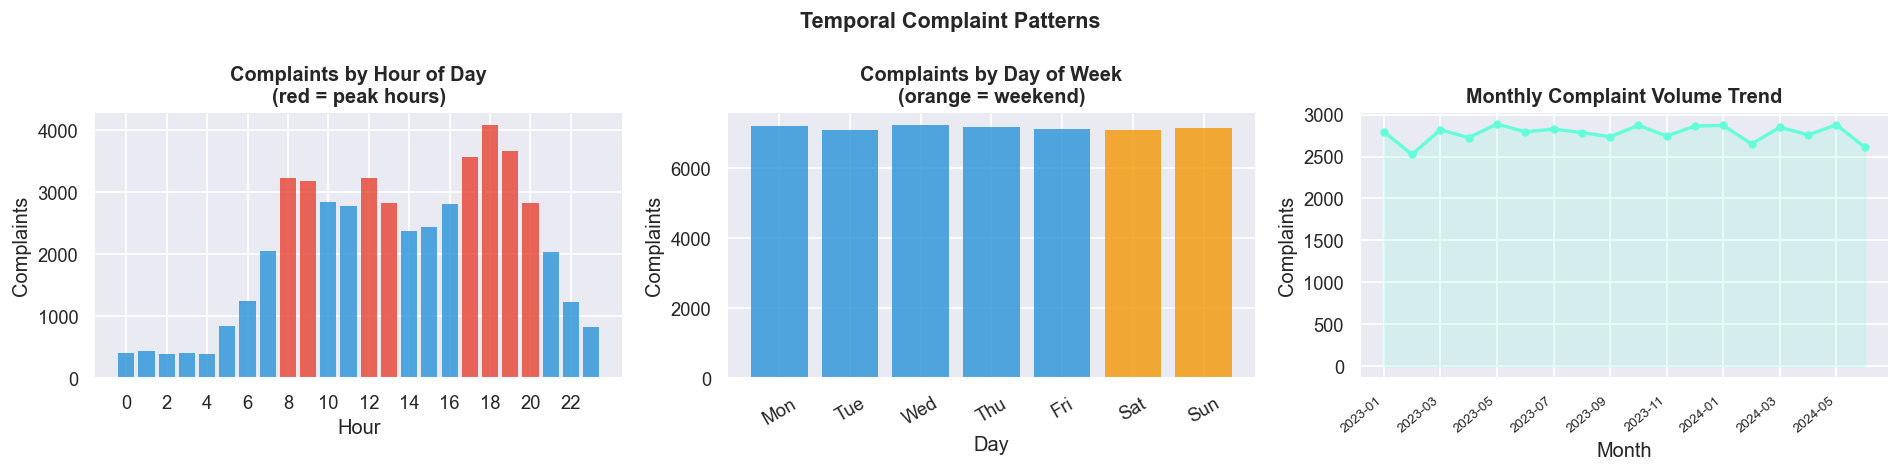

Peak hour: 18:00 | Peak/off-peak ratio: 1.13x


In [7]:
hourly  = results['hourly_patterns']
dow     = results['dow_patterns']
monthly = results['monthly_trends']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4.1 Hourly distribution
bar_c = ['#e74c3c' if row['is_peak'] else '#3498db'
          for _, row in hourly.iterrows()]
axes[0].bar(hourly['hour'], hourly['complaint_count'],
            color=bar_c, edgecolor='none', alpha=0.85)
axes[0].set_title('Complaints by Hour of Day\n(red = peak hours)',
                   fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Complaints')
axes[0].set_xticks(range(0, 24, 2))

# 4.2 Day-of-week distribution
dow_c = ['#f39c12' if w else '#3498db'
          for w in dow['is_weekend']]
axes[1].bar(range(len(dow)), dow['complaint_count'],
            color=dow_c, edgecolor='none', alpha=0.85)
axes[1].set_xticks(range(len(dow)))
axes[1].set_xticklabels(
    [d[:3] for d in dow['day_of_week']],
    rotation=30
)
axes[1].set_title('Complaints by Day of Week\n(orange = weekend)',
                   fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Complaints')

# 4.3 Monthly trend
if 'total' in monthly.columns:
    axes[2].plot(range(len(monthly)), monthly['total'],
                 marker='o', markersize=4, color='#64ffda', linewidth=2)
    axes[2].fill_between(range(len(monthly)), monthly['total'],
                          alpha=0.15, color='#64ffda')
    axes[2].set_xticks(range(0, len(monthly), 2))
    axes[2].set_xticklabels(
        monthly['month_label'].iloc[::2], rotation=40, ha='right', fontsize=8
    )
    axes[2].set_title('Monthly Complaint Volume Trend', fontweight='bold')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Complaints')

plt.suptitle('Temporal Complaint Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_temporal_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()

peak_h = hourly.loc[hourly['complaint_count'].idxmax(), 'hour']
ratio  = hourly['peak_vs_offpeak_ratio'].iloc[0]
print(f'Peak hour: {peak_h:02d}:00 | Peak/off-peak ratio: {ratio:.2f}x')

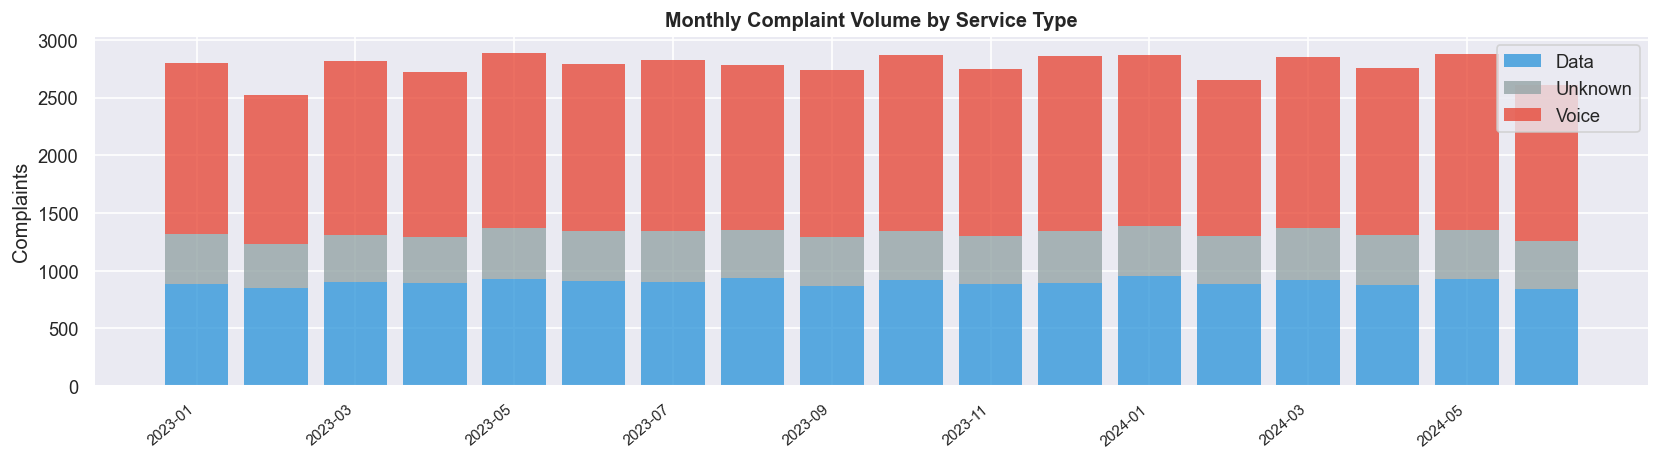

In [8]:
# 4.4 Monthly stacked area by service type
svc_cols = [c for c in monthly.columns
            if c not in ('month_label','total')
            and not c.endswith('_pct')]

if svc_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    x = range(len(monthly))
    bottom = np.zeros(len(monthly))
    palette = {'Data':'#3498db','Voice':'#e74c3c','Unknown':'#95a5a6',
               'SMS':'#2ecc71'}
    for col in svc_cols:
        color = palette.get(col, '#9b59b6')
        ax.bar(x, monthly[col], bottom=bottom, label=col,
               color=color, alpha=0.8, edgecolor='none')
        bottom += monthly[col].values

    ax.set_xticks(range(0, len(monthly), 2))
    ax.set_xticklabels(
        monthly['month_label'].iloc[::2], rotation=40, ha='right', fontsize=9
    )
    ax.set_title('Monthly Complaint Volume by Service Type',
                  fontweight='bold')
    ax.set_ylabel('Complaints')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_monthly_service_stacked.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 5. Hour × Day-of-Week Heatmap

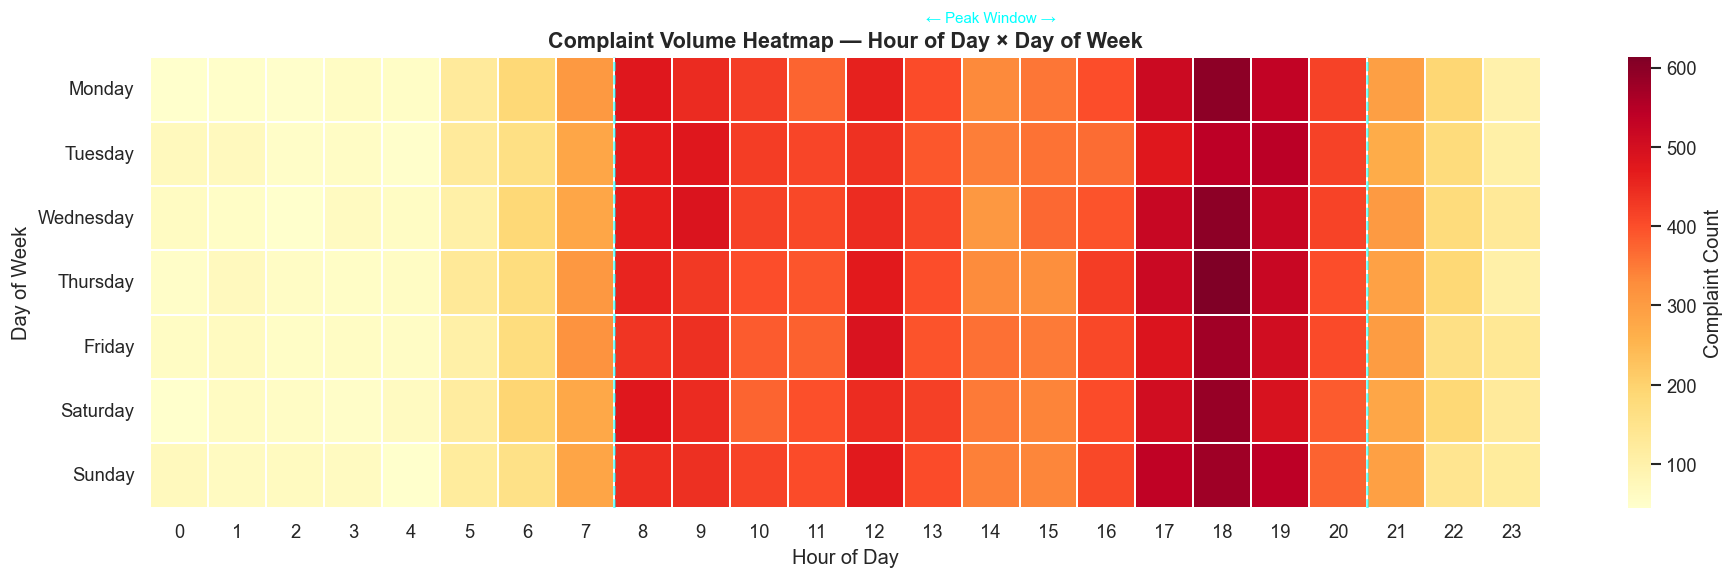

In [9]:
hour_dow = results['hour_dow_heatmap']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    hour_dow, cmap='YlOrRd',
    linewidths=0.2, ax=ax,
    cbar_kws={'label': 'Complaint Count'},
    fmt='d', annot=False
)
ax.set_title(
    'Complaint Volume Heatmap — Hour of Day × Day of Week',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

# Mark peak zone
peak_hours_list = sorted([8,9,12,13,17,18,19,20])
ax.axvline(x=8,  color='cyan', linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=21, color='cyan', linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(14.5, -0.5, '← Peak Window →', color='cyan',
        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/st_hour_dow_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

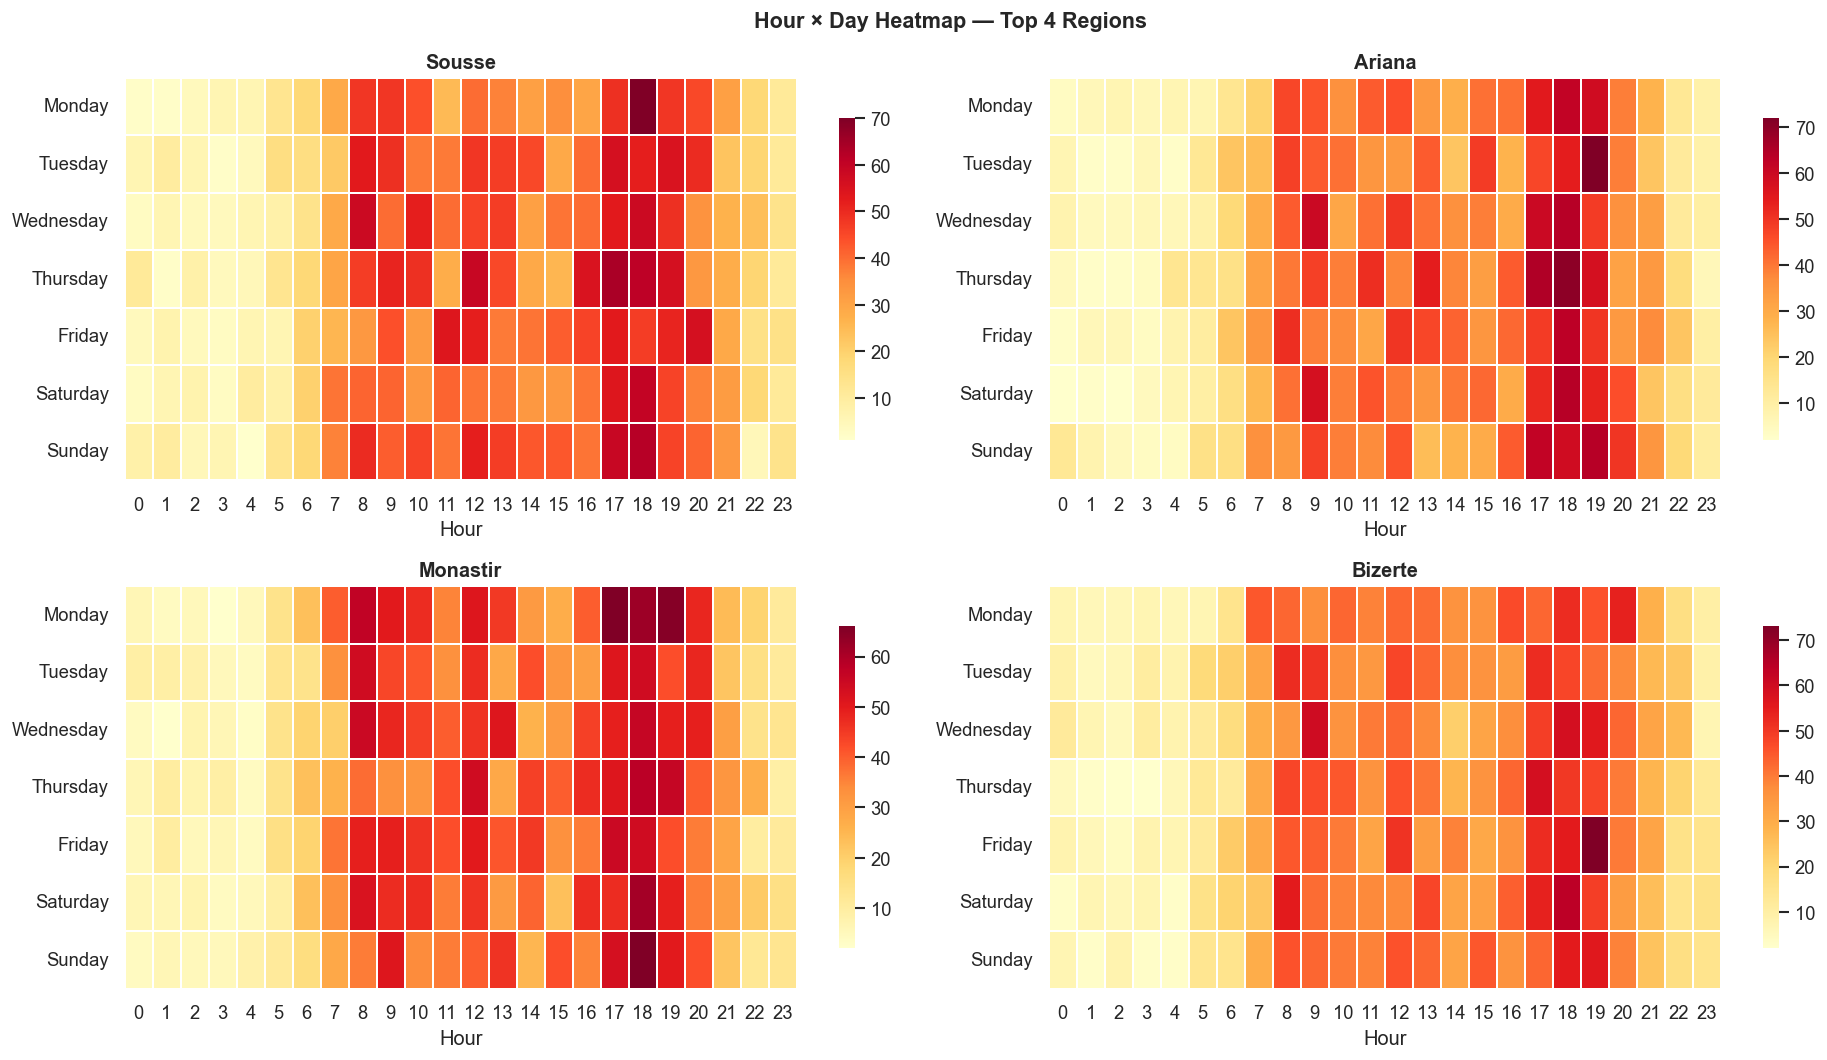

In [10]:
# 5.2 Heatmap per region (subset — top 4 regions)
top4_regions = results['regional_hotspots']['region'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

for i, region in enumerate(top4_regions):
    reg_df = complaints_clean[complaints_clean['region'] == region]
    pivot  = (
        reg_df.groupby(['day_of_week','hour'])
               .size().unstack(fill_value=0)
               .reindex(DOW_ORDER)
    )
    sns.heatmap(
        pivot, cmap='YlOrRd', ax=axes[i],
        linewidths=0.2, cbar=True,
        cbar_kws={'shrink': 0.8}
    )
    axes[i].set_title(f'{region}', fontweight='bold')
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('')

plt.suptitle('Hour × Day Heatmap — Top 4 Regions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_hour_dow_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Anomaly Burst Detection

In [11]:
bursts = results['anomaly_bursts']
if bursts.empty:
    print('No burst events detected.')
else:
    print(f'Total burst events: {len(bursts)}')
    display(bursts[['region','burst_start','burst_end',
                    'duration_days','total_complaints',
                    'peak_zscore','severity']].head(15))

Total burst events: 143


,region,burst_start,burst_end,duration_days,total_complaints,peak_zscore,severity
0,Bizerte,2023-10-05,2023-10-05,1,21,3.98,Critical
1,Monastir,2024-03-18,2024-03-18,1,20,3.54,Critical
2,Bizerte,2023-08-28,2023-08-28,1,19,3.31,Critical
3,Bizerte,2023-03-15,2023-03-15,1,19,3.31,Critical
4,Tunis,2023-10-08,2023-10-08,1,18,3.28,Critical
5,Tunis,2024-06-22,2024-06-22,1,18,3.28,Critical
6,Ariana,2023-09-15,2023-09-15,1,19,3.20,Critical
7,Ariana,2024-05-06,2024-05-06,1,19,3.20,Critical
8,Sousse,2023-11-18,2023-11-18,1,19,3.18,Critical
9,Sousse,2023-12-06,2023-12-06,1,19,3.18,Critical


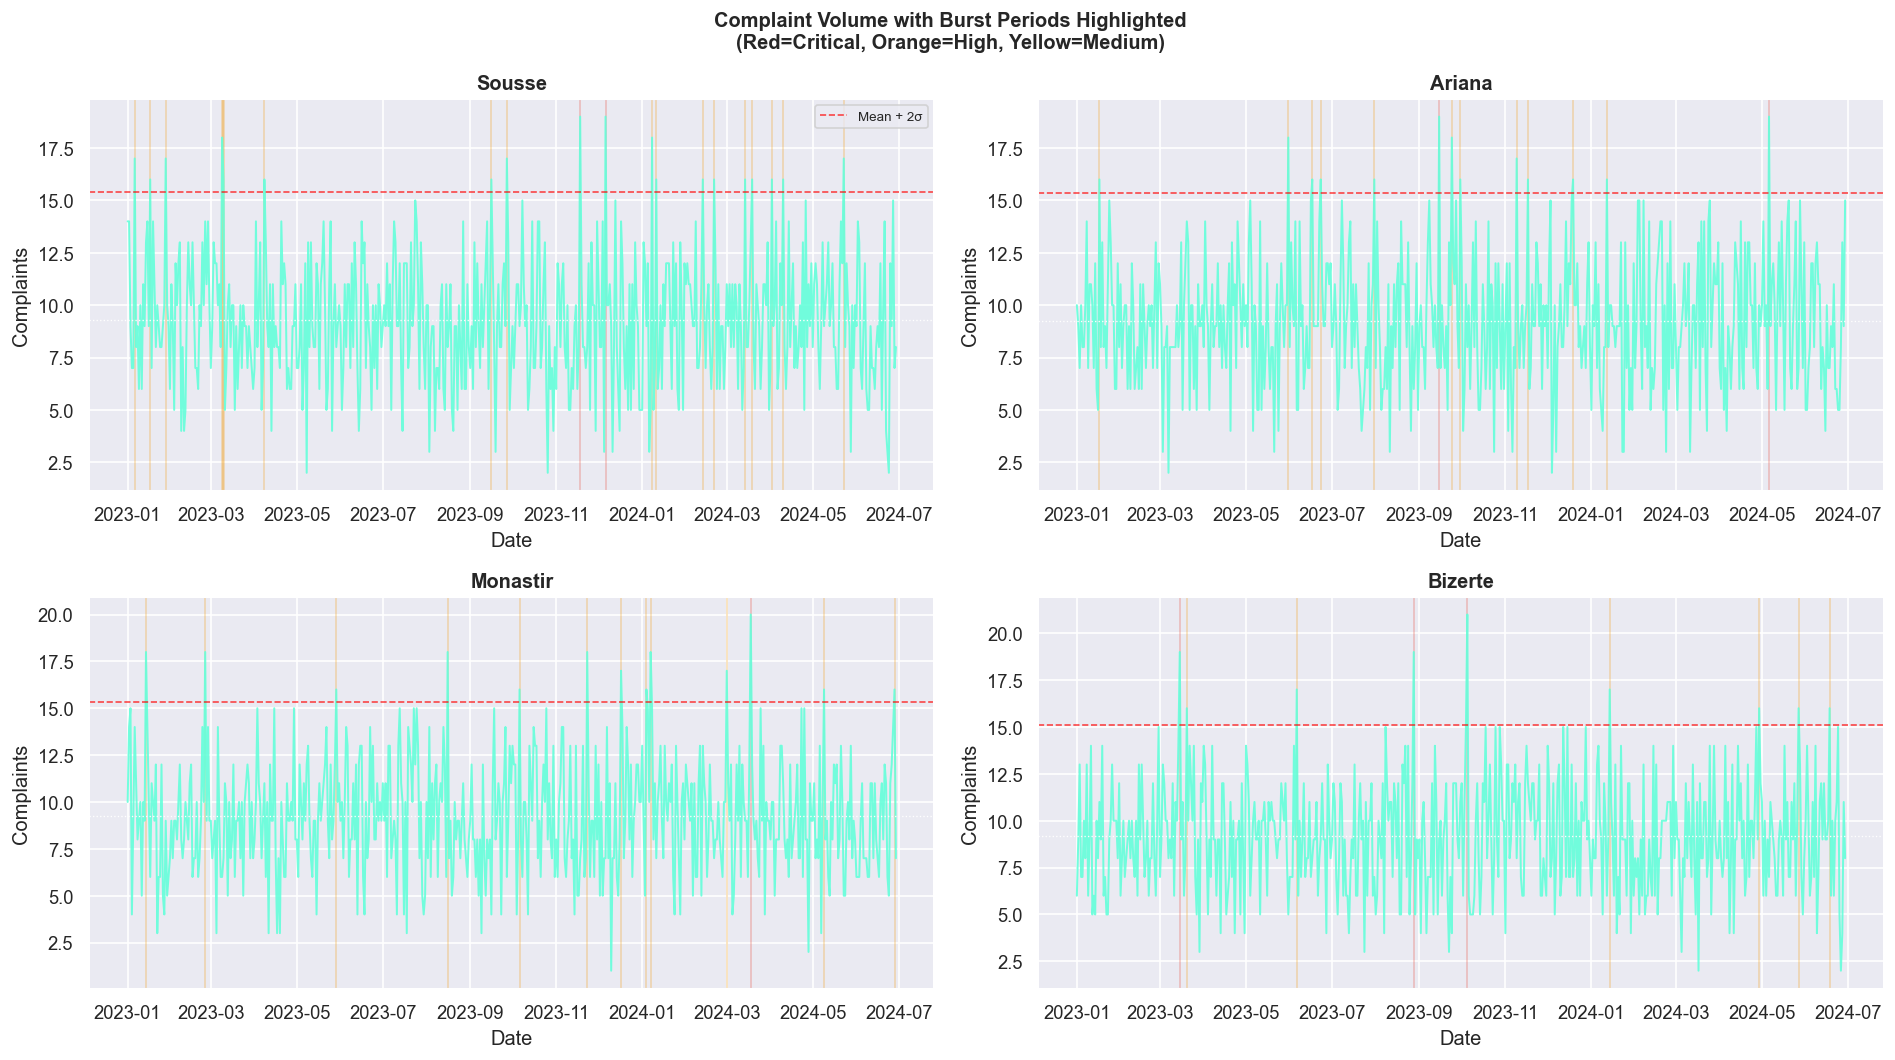

In [12]:
# 6.1 Complaint time series with burst periods highlighted
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=False)
axes = axes.flatten()

top4_regions = results['regional_hotspots']['region'].head(4).tolist()

for i, region in enumerate(top4_regions):
    ca_r    = complaint_agg[complaint_agg['region']==region].sort_values('date')
    bursts_r= bursts[bursts['region']==region] if not bursts.empty else pd.DataFrame()

    axes[i].plot(ca_r['date'], ca_r['total_complaints'],
                 color='#64ffda', linewidth=1.2, alpha=0.9)

    # Shade burst periods
    if not bursts_r.empty:
        for _, burst in bursts_r.iterrows():
            color = ('#e74c3c' if burst['severity']=='Critical' else
                     '#f39c12' if burst['severity']=='High' else '#f1c40f')
            axes[i].axvspan(
                burst['burst_start'], burst['burst_end'],
                alpha=0.3, color=color
            )

    # Mean ± 2σ lines
    m  = ca_r['total_complaints'].mean()
    s  = ca_r['total_complaints'].std()
    axes[i].axhline(m + 2*s, color='red',
                    linestyle='--', linewidth=1, alpha=0.7,
                    label='Mean + 2σ')
    axes[i].axhline(m, color='white', linestyle=':', linewidth=0.8)

    axes[i].set_title(f'{region}', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Complaints')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle(
    'Complaint Volume with Burst Periods Highlighted\n'
    '(Red=Critical, Orange=High, Yellow=Medium)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_burst_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

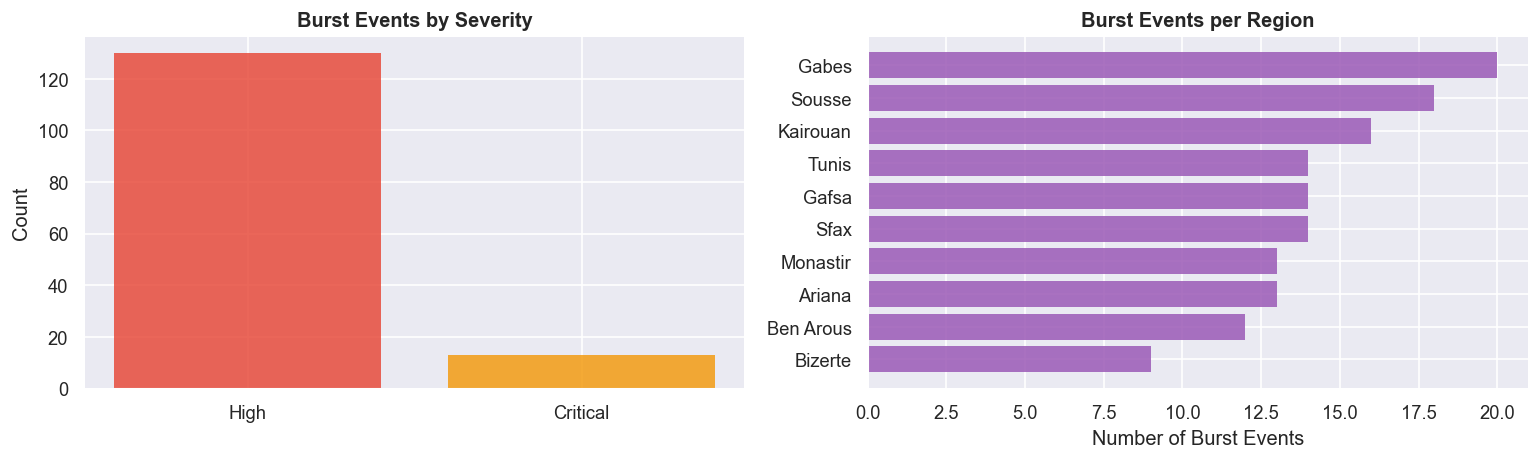

In [13]:
# 6.2 Burst severity distribution
if not bursts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Severity counts
    sev_counts = bursts['severity'].value_counts()
    axes[0].bar(sev_counts.index, sev_counts.values,
                color=['#e74c3c','#f39c12','#f1c40f'],
                edgecolor='none', alpha=0.85)
    axes[0].set_title('Burst Events by Severity', fontweight='bold')
    axes[0].set_ylabel('Count')

    # Bursts per region
    burst_per_region = bursts.groupby('region').size().sort_values()
    axes[1].barh(burst_per_region.index, burst_per_region.values,
                 color='#9b59b6', edgecolor='none', alpha=0.85)
    axes[1].set_title('Burst Events per Region', fontweight='bold')
    axes[1].set_xlabel('Number of Burst Events')

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_burst_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 7. Service-Type Segmentation by Region

In [14]:
svc = results['service_by_region']
display(svc)

service_type,region,Data,Unknown,Voice,Data_pct,Unknown_pct,Voice_pct,dominant_service
0,Ariana,1910,661,2485,37.8,13.1,49.1,Voice
1,Ben Arous,1923,674,2399,38.5,13.5,48.0,Voice
2,Bizerte,1627,724,2663,32.4,14.4,53.1,Voice
3,Gabes,1317,921,2730,26.5,18.5,55.0,Voice
4,Gafsa,1199,851,2897,24.2,17.2,58.6,Voice
5,Kairouan,1577,804,2619,31.5,16.1,52.4,Voice
6,Monastir,1559,798,2693,30.9,15.8,53.3,Voice
7,Sfax,1598,750,2654,31.9,15.0,53.1,Voice
8,Sousse,1621,791,2664,31.9,15.6,52.5,Voice
9,Tunis,1866,646,2379,38.2,13.2,48.6,Voice


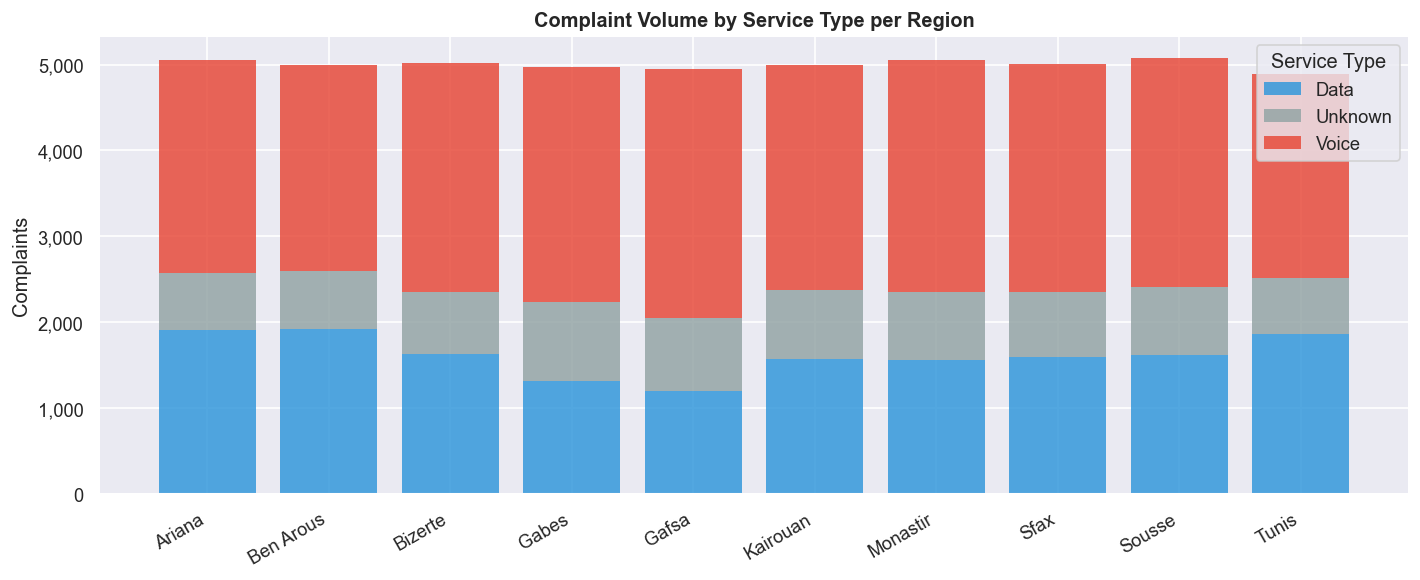

In [15]:
# 7.1 Stacked bar — service type mix per region
svc_cols = [c for c in svc.columns
            if c not in ('region','dominant_service')
            and not c.endswith('_pct')]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(svc))
bottom  = np.zeros(len(svc))
palette = {'Data':'#3498db','Voice':'#e74c3c',
           'Unknown':'#95a5a6','SMS':'#2ecc71'}

for col in svc_cols:
    color = palette.get(col, '#9b59b6')
    ax.bar(x, svc[col], bottom=bottom, label=col,
           color=color, alpha=0.85, edgecolor='none')
    bottom += svc[col].values

ax.set_xticks(x)
ax.set_xticklabels(svc['region'], rotation=30, ha='right')
ax.set_title('Complaint Volume by Service Type per Region',
              fontweight='bold')
ax.set_ylabel('Complaints')
ax.legend(title='Service Type', loc='upper right')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_service_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

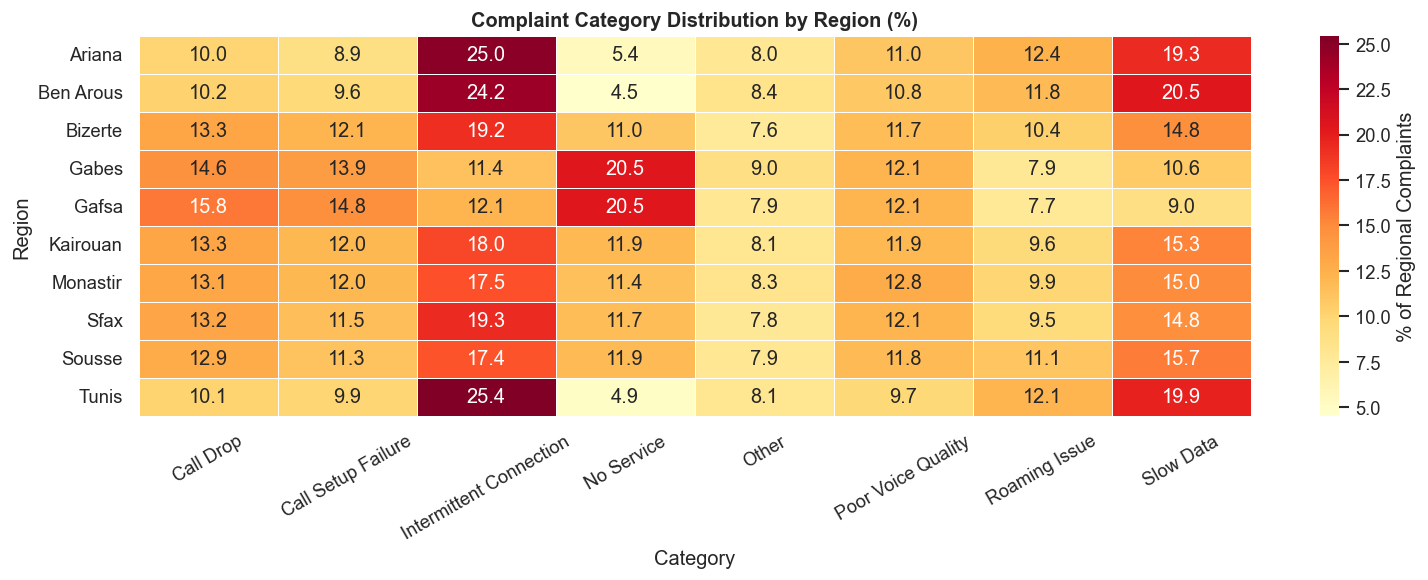

In [16]:
# 7.2 Complaint category breakdown per region — heatmap
cat_cols = [c for c in complaint_agg.columns if c.startswith('cat_')]
cat_pivot = (
    complaint_agg.groupby('region')[cat_cols]
                  .sum()
)
cat_pivot.columns = [
    c.replace('cat_','').replace('_',' ').title()
    for c in cat_pivot.columns
]
# Normalise per region
cat_norm = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    cat_norm, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': '% of Regional Complaints'}
)
ax.set_title('Complaint Category Distribution by Region (%)',
              fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Region')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_category_by_region_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Cell-Level Hotspot Analysis

In [17]:
cells = results['cell_hotspots']
print('=== Top 20 Cell Hotspots ===')
display(cells[['cell_rank','cell_id','region',
               'total_complaints','dominant_category']].to_string(index=False))

=== Top 20 Cell Hotspots ===


' cell_rank   cell_id    region  total_complaints       dominant_category\n         1 CELL_0036      Sfax                46 Intermittent Connection\n         2 CELL_0086    Ariana                42 Intermittent Connection\n         3 CELL_0048 Ben Arous                41 Intermittent Connection\n         4 CELL_0028  Kairouan                41 Intermittent Connection\n         5 CELL_0130  Monastir                40 Intermittent Connection\n         6 CELL_0197  Kairouan                40 Intermittent Connection\n         7 CELL_0195     Gafsa                40               Slow Data\n         8 CELL_0144     Tunis                39               Slow Data\n         9 CELL_0009      Sfax                39      Call Setup Failure\n        10 CELL_0179    Sousse                39 Intermittent Connection\n        11 CELL_0109   Bizerte                39      Call Setup Failure\n        12 CELL_0092  Monastir                38               Call Drop\n        13 CELL_0112   Bizerte       

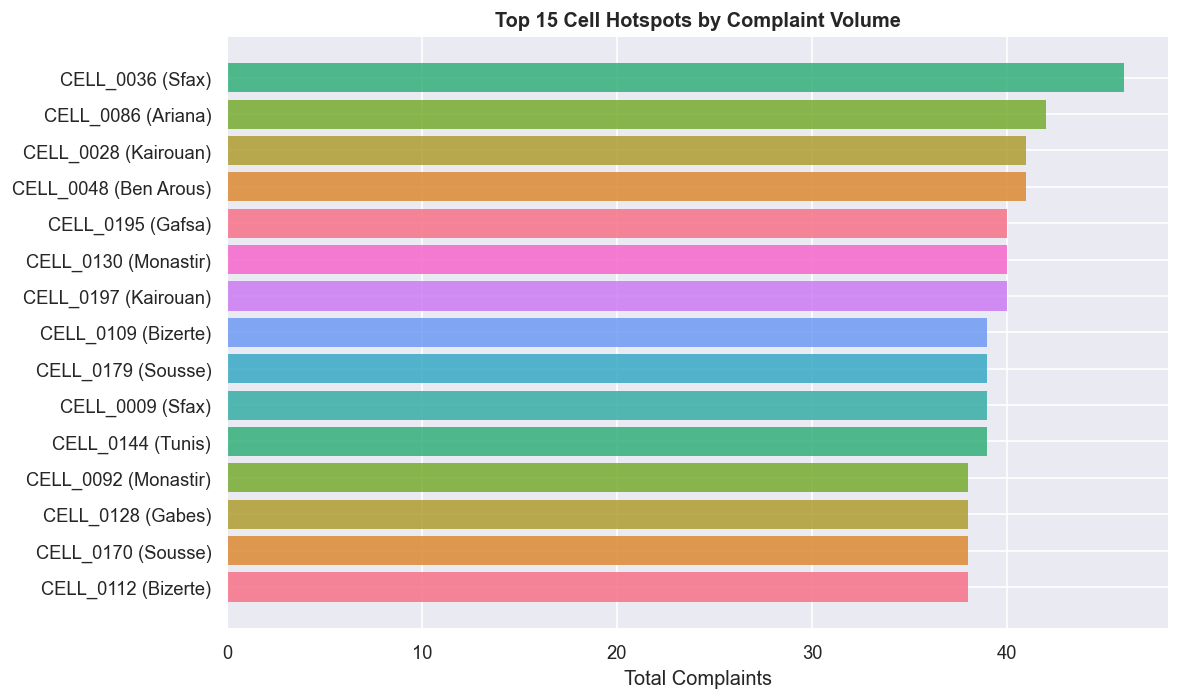

In [18]:
# 8.1 Top 15 cells bar chart
top15 = cells.head(15).sort_values('total_complaints')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15['cell_id'] + ' (' + top15['region'] + ')',
    top15['total_complaints'],
    color=COLORS[:len(top15)], edgecolor='none', alpha=0.85
)
ax.set_title('Top 15 Cell Hotspots by Complaint Volume',
              fontweight='bold')
ax.set_xlabel('Total Complaints')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_cell_hotspots.png',
            dpi=150, bbox_inches='tight')
plt.show()

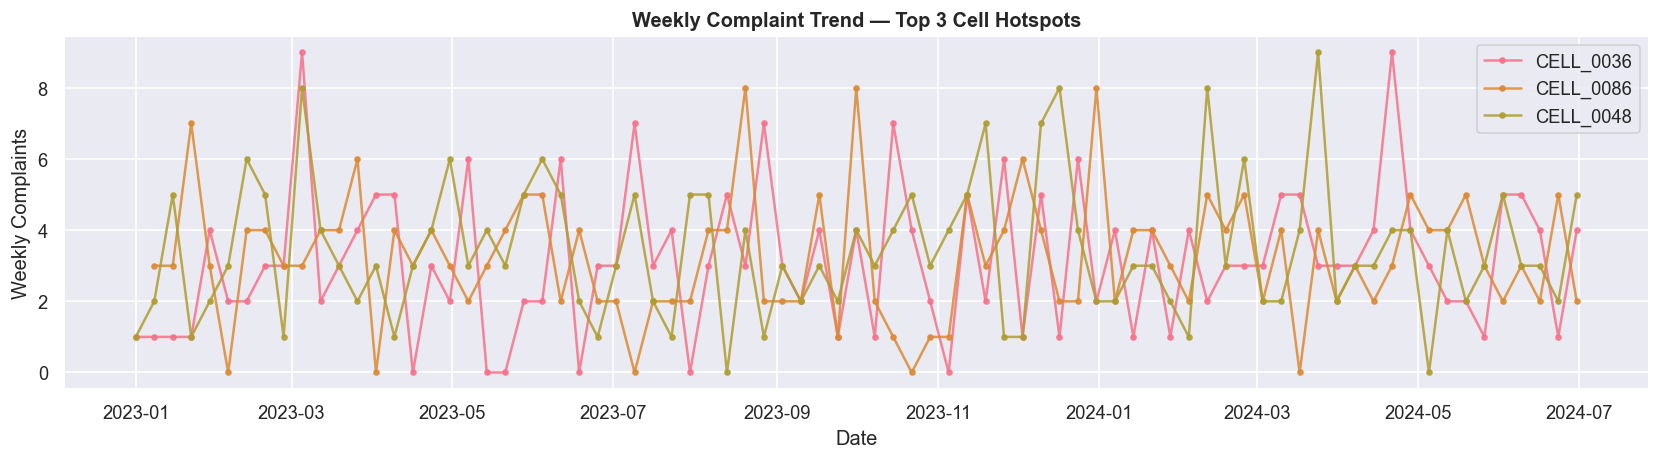

In [19]:
# 8.2 Complaint trend for top 3 cells over time
top3_cells = cells.head(3)['cell_id'].tolist()

complaints_clean['date'] = pd.to_datetime(complaints_clean['timestamp']).dt.date
cell_trend = (
    complaints_clean[
        complaints_clean['cell_id'].isin(top3_cells)
    ]
    .groupby(['date','cell_id'])
    .size().reset_index(name='count')
)
cell_trend['date'] = pd.to_datetime(cell_trend['date'])
# Weekly resample
cell_trend_w = (
    cell_trend.set_index('date')
               .groupby('cell_id')['count']
               .resample('W').sum()
               .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
for i, cell in enumerate(top3_cells):
    ct = cell_trend_w[cell_trend_w['cell_id'] == cell]
    ax.plot(ct['date'], ct['count'], linewidth=1.5,
            marker='o', markersize=3,
            color=COLORS[i], label=cell, alpha=0.85)

ax.set_title('Weekly Complaint Trend — Top 3 Cell Hotspots',
              fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Complaints')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_cell_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [20]:
summary = results['summary']

print('=' * 60)
print('  SPATIO-TEMPORAL ANALYSIS — KEY FINDINGS')
print('=' * 60)

if 'top_hotspot_region' in summary:
    print(f'\n  Geographic hotspot:')
    print(f'    Top region    : {summary["top_hotspot_region"]}')
    print(f'    Total complaints: {summary["top_hotspot_complaints"]:,}')
    print(f'    Dominant issue: {summary["top_hotspot_category"]}')

if 'peak_hour' in summary:
    print(f'\n  Temporal patterns:')
    print(f'    Peak hour     : {summary["peak_hour"]:02d}:00 '
          f'({summary["peak_hour_label"]})')
    print(f'    Peak/off-peak : {summary["peak_offpeak_ratio"]:.2f}x more complaints')

if 'total_burst_events' in summary:
    print(f'\n  Burst events:')
    print(f'    Total         : {summary["total_burst_events"]}')
    print(f'    Critical      : {summary["critical_bursts"]}')
    print(f'    Most bursty   : {summary["most_bursty_region"]}')

print(f'\n  Figures saved to reports/figures/       ✓')
print(f'  CSV tables saved to reports/exports/    ✓')
print(f'  Interactive map: reports/exports/st_regional_map.html ✓')
print('=' * 60)

import os
st_files = sorted([f for f in os.listdir('reports/exports') if f.startswith('st_')])
print('\nST files produced:')
for f in st_files:
    print(f'  reports/exports/{f}')

  SPATIO-TEMPORAL ANALYSIS — KEY FINDINGS

  Geographic hotspot:
    Top region    : Sousse
    Total complaints: 5,076
    Dominant issue: Intermittent Connection

  Temporal patterns:
    Peak hour     : 18:00 (Evening (17-20))
    Peak/off-peak : 1.13x more complaints

  Burst events:
    Total         : 143
    Critical      : 13
    Most bursty   : Gabes

  Figures saved to reports/figures/       ✓
  CSV tables saved to reports/exports/    ✓
  Interactive map: reports/exports/st_regional_map.html ✓

ST files produced:
  reports/exports/st_anomaly_bursts.csv
  reports/exports/st_cell_hotspots.csv
  reports/exports/st_dow_patterns.csv
  reports/exports/st_hourly_patterns.csv
  reports/exports/st_monthly_trends.csv
  reports/exports/st_regional_hotspots.csv
  reports/exports/st_regional_map.html
  reports/exports/st_service_by_region.csv
